In [2]:
import os
import re
import unicodedata
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

def clean_text(text):
    """Normalize text, remove diacritics/accents, lower string, and fix suffixes."""
    if pd.isna(text):
        return ""
    
    # Normalize unicode (handles French accent marks e.g. 'é' -> 'e')
    text = unicodedata.normalize('NFKD', str(text)).encode('ASCII', 'ignore').decode('utf-8')
    text = text.lower()
    
    # Expand/normalize legal suffixes and noise
    replacements = {
        r'\bcorp\b|\bcorporation\b': 'corp',
        r'\bpvt\b|\bprivate\b': 'pvt',
        r'\bltd\b|\blimited\b': 'ltd',
        r'\binc\b|\bincorporated\b': 'inc',
        r'\b&amp;\b|\b&\b': ' and ',
        r'\brd\b|\broad\b': 'road',
        r'\bst\b|\bstreet\b': 'street',
    }
    for pattern, repl in replacements.items():
        text = re.sub(pattern, repl, text)
        
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def process_source(df):
    """Combine name and address fields for vectorization"""
    df['clean_name'] = df['business_name'].apply(clean_text)
    df['clean_address'] = df['business_address'].apply(clean_text)
    df['combined_text'] = df['clean_name'] + " " + df['clean_address']
    return df

In [6]:
def generate_matches_for_block(s1_df, cand_df, top_k=25, match_threshold=0.85):
    """
    Computes Sparse Character n-gram TF-IDF Cosine Similarity.
    Generates high-recall candidates and high-precision matches for F0.5 optimization.
    """
    vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4), min_df=2)
    
    all_texts = pd.concat([s1_df['combined_text'], cand_df['combined_text']])
    vectorizer.fit(all_texts)
    
    s1_tfidf = vectorizer.transform(s1_df['combined_text'])
    cand_tfidf = vectorizer.transform(cand_df['combined_text'])
    
    # Matrix Multiplication (S1 x Candidates^T)
    similarity_matrix = s1_tfidf.dot(cand_tfidf.T)
    
    candidates_dict = {}
    matches_dict = {}
    
    for i, s1_id in enumerate(s1_df['entity_id']):
        row_sims = similarity_matrix.getrow(i).toarray()[0]
        
        # Extract Top-K candidate indices sorted by similarity score
        top_indices = np.argsort(row_sims)[-top_k:][::-1]
        
        c_list = []
        m_list = []
        
        for idx in top_indices:
            score = row_sims[idx]
            cand_id = cand_df.iloc[idx]['entity_id']
            
            if score > 0.05:  # Loose threshold for candidate_pairs.tsv (High Recall)
                c_list.append(cand_id)
            if score >= match_threshold:  # Strict cutoff for matching_results.tsv (High Precision)
                m_list.append(cand_id)
                
        candidates_dict[s1_id] = c_list
        matches_dict[s1_id] = m_list
        
    return candidates_dict, matches_dict

In [8]:
import os
from pathlib import Path

print(f"Current Notebook Working Directory:\n{os.getcwd()}\n")

# Search for the test files automatically in the current working directory
s1_matches = list(Path('.').rglob('*test_source1.tsv'))

if s1_matches:
    test_dir = s1_matches[0].parent
    print(f"Successfully found test files in folder:\n{test_dir.resolve()}")
else:
    print("Could not find 'test_source1.tsv' in this folder or its subfolders.")

Current Notebook Working Directory:
/Users/tanmayrath/Desktop/Rookies_submission/code/business_entity_resolution/src

Successfully found test files in folder:
/Users/tanmayrath/Desktop/Rookies_submission/code/business_entity_resolution/src


DATA LOADING

In [11]:
import os
import pandas as pd
import numpy as np

# Resolve base directory whether running inside src/ or root
def get_data_path(relative_path):
    if os.path.exists(relative_path):
        return relative_path
    elif os.path.exists(os.path.join("../../", relative_path)):
        return os.path.join("../../", relative_path)
    elif os.path.exists(os.path.join("../", relative_path)):
        return os.path.join("../", relative_path)
    else:
        raise FileNotFoundError(f"Cannot find {relative_path}")
        

# Load Training Data
train_s1 = pd.read_csv(get_data_path("train_source1.tsv"), sep="\t")
train_s2 = pd.read_csv(get_data_path("train_source2.tsv"), sep="\t")
train_s3 = pd.read_csv(get_data_path("train_source3.tsv"), sep="\t")
gt = pd.read_csv(get_data_path("train_ground_truth.tsv"), sep="\t")

# Load Test Data
test_s1 = pd.read_csv(get_data_path("test_source1.tsv"), sep="\t")
test_s2 = pd.read_csv(get_data_path("test_source2.tsv"), sep="\t")
test_s3 = pd.read_csv(get_data_path("test_source3.tsv"), sep="\t")

print("=== RECORD COUNTS ===")
print(f"Train - Source 1: {len(train_s1):,}")
print(f"Train - Source 2: {len(train_s2):,}")
print(f"Train - Source 3: {len(train_s3):,}")
print(f"Train - Ground Truth Rows: {len(gt):,}\n")
print(f"Test  - Source 1: {len(test_s1):,}")
print(f"Test  - Source 2: {len(test_s2):,}")
print(f"Test  - Source 3: {len(test_s3):,}")

=== RECORD COUNTS ===
Train - Source 1: 2,206,821
Train - Source 2: 5,034,616
Train - Source 3: 5,285,603
Train - Ground Truth Rows: 2,206,821

Test  - Source 1: 1,732,544
Test  - Source 2: 4,887,273
Test  - Source 3: 5,082,316


In [13]:
import numpy as np

print("=== GROUND TRUTH DISTRIBUTION ===")

# Vectorized check for singletons (NaN or empty strings)
singletons_mask = gt['matched_entity_ids'].isna() | (gt['matched_entity_ids'] == '')
singletons = singletons_mask.sum()
total_entities = len(gt)
matched_entities = total_entities - singletons

print(f"Total Source 1 Entities: {total_entities:,}")
print(f"Singletons (0 matches):  {singletons:,} ({(singletons / total_entities) * 100:.2f}%)")
print(f"Matched (>= 1 match):    {matched_entities:,} ({(matched_entities / total_entities) * 100:.2f}%)\n")

print("=== MATCH COUNT FREQUENCY ===")
# Fast match counting: Count commas and add 1 for non-singletons
match_counts = gt.loc[~singletons_mask, 'matched_entity_ids'].str.count(',') + 1

print(f"0 matches: {singletons:,}")
print(match_counts.value_counts().sort_index().to_string())

print("\n=== SOURCE BREAKDOWN OF MATCHES ===")
# Fast substring matching to see if S2 or S3 IDs exist in the match strings
has_s2 = gt.loc[~singletons_mask, 'matched_entity_ids'].str.contains('S2-')
has_s3 = gt.loc[~singletons_mask, 'matched_entity_ids'].str.contains('S3-')

print(f"Entities with S2 match: {has_s2.sum():,}")
print(f"Entities with S3 match: {has_s3.sum():,}")
print(f"Entities with BOTH S2 and S3 matches: {(has_s2 & has_s3).sum():,}")


=== GROUND TRUTH DISTRIBUTION ===
Total Source 1 Entities: 2,206,821
Singletons (0 matches):  123,247 (5.58%)
Matched (>= 1 match):    2,083,574 (94.42%)

=== MATCH COUNT FREQUENCY ===
0 matches: 123,247
matched_entity_ids
1     119157
2     375212
3     530841
4     484115
5     321957
6     164868
7      63968
8      18680
9       4205
10       534
11        37

=== SOURCE BREAKDOWN OF MATCHES ===
Entities with S2 match: 1,919,076
Entities with S3 match: 1,940,545
Entities with BOTH S2 and S3 matches: 1,776,047


In [15]:
print("=== MISSING VALUE ANALYSIS ===")

# Build a summary dataframe for null counts across all 6 files
null_summary = pd.DataFrame({
    'Train S1': train_s1.isnull().sum(),
    'Train S2': train_s2.isnull().sum(),
    'Train S3': train_s3.isnull().sum(),
    'Test S1': test_s1.isnull().sum(),
    'Test S2': test_s2.isnull().sum(),
    'Test S3': test_s3.isnull().sum()
}).T

# Format with commas for readability
print(null_summary.map(lambda x: f"{x:,}"))

=== MISSING VALUE ANALYSIS ===
         entity_id business_name business_address country
Train S1         0             0                0       0
Train S2         0             2          168,967       0
Train S3         0            13          175,916       0
Test S1          0             0                0       0
Test S2          0            46          129,408       0
Test S3          0            59          136,098       0


HEATMAPS

/var/folders/k4/gcqzln6s2cq89xq1z0mg0b0h0000gn/T/ipykernel_25533/3558800237.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=match_counts.value_counts().index,


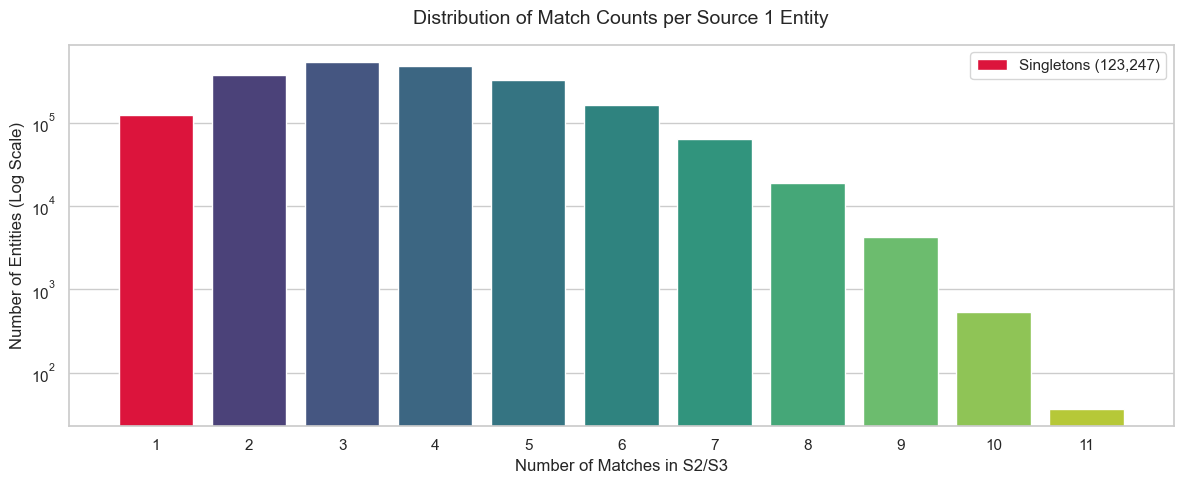

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid", context="notebook")

plt.figure(figsize=(12, 5))
# Using the match_counts calculated in the previous step
ax = sns.barplot(x=match_counts.value_counts().index, 
                 y=match_counts.value_counts().values, 
                 palette="viridis")

plt.title("Distribution of Match Counts per Source 1 Entity", fontsize=14, pad=15)
plt.xlabel("Number of Matches in S2/S3", fontsize=12)
plt.ylabel("Number of Entities (Log Scale)", fontsize=12)
plt.yscale('log') # Log scale because of the massive variance

# Annotate the singleton bar specifically
singleton_count = singletons
plt.bar(0, singleton_count, color='crimson', label=f'Singletons ({singleton_count:,})')
plt.legend()
plt.tight_layout()
plt.show()

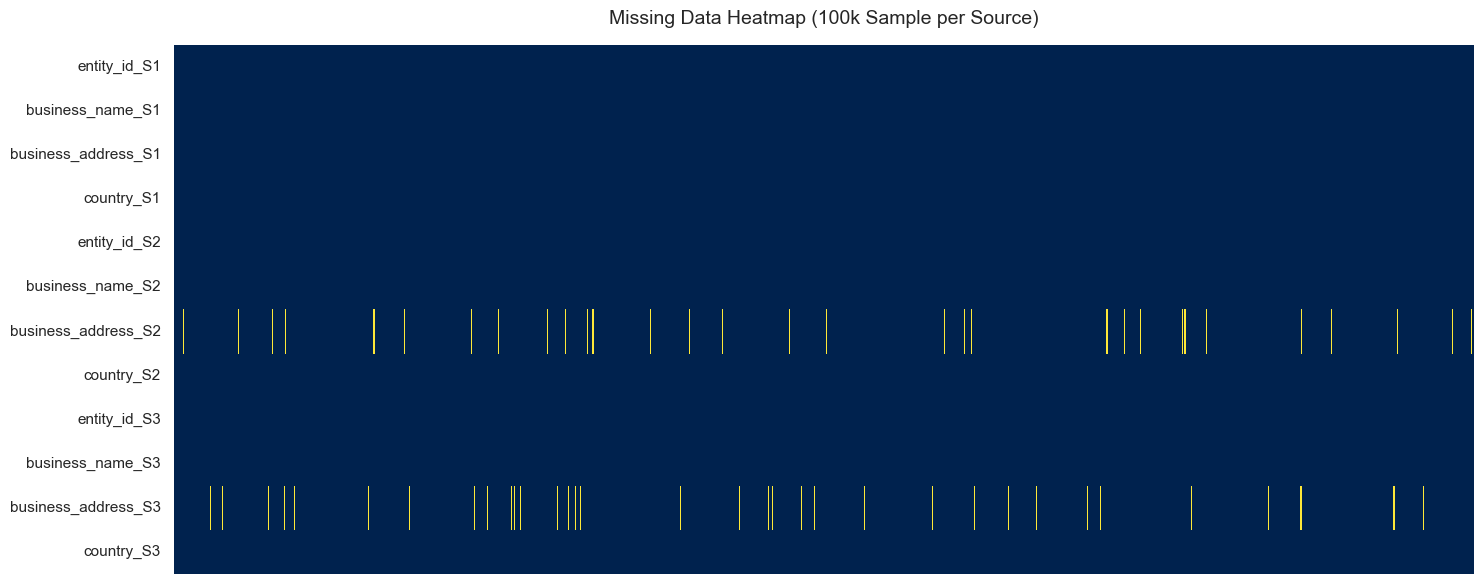

In [19]:
plt.figure(figsize=(15, 6))

# Sample down and reset index so all dataframes align from row 0 to N
sample_s1 = train_s1.sample(min(100000, len(train_s1)), random_state=42).reset_index(drop=True)
sample_s2 = train_s2.sample(min(100000, len(train_s2)), random_state=42).reset_index(drop=True)
sample_s3 = train_s3.sample(min(100000, len(train_s3)), random_state=42).reset_index(drop=True)

# Create a combined missing value matrix and cast to float for Seaborn
missing_matrix = pd.concat([
    sample_s1.isnull().add_suffix('_S1'), 
    sample_s2.isnull().add_suffix('_S2'), 
    sample_s3.isnull().add_suffix('_S3')
], axis=1).astype(float)

# Plot heatmap (black = data exists, yellow = missing data)
sns.heatmap(missing_matrix.transpose(), 
            cmap="cividis", 
            cbar=False, 
            yticklabels=True, 
            xticklabels=False)

plt.title("Missing Data Heatmap (100k Sample per Source)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

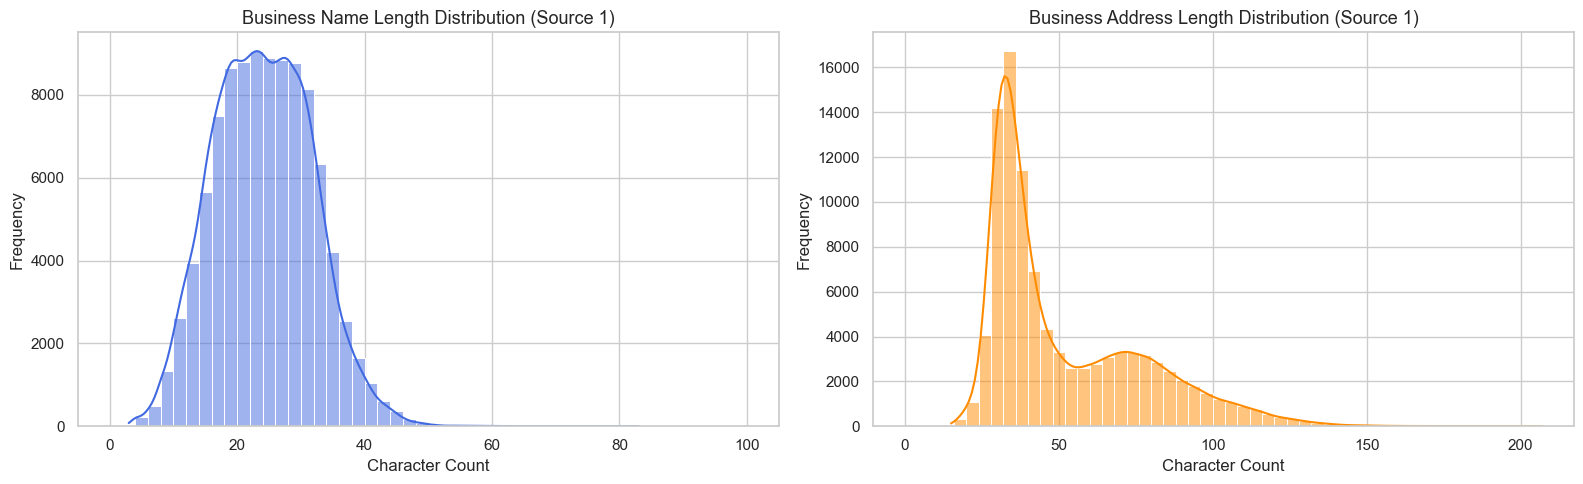

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Calculate string lengths (handling NaNs)
s1_name_len = sample_s1['business_name'].dropna().apply(len)
s1_addr_len = sample_s1['business_address'].dropna().apply(len)

# Plot Name Lengths
sns.histplot(s1_name_len, bins=50, ax=axes[0], color="royalblue", kde=True, binrange=(0, 100))
axes[0].set_title("Business Name Length Distribution (Source 1)", fontsize=13)
axes[0].set_xlabel("Character Count")
axes[0].set_ylabel("Frequency")

# Plot Address Lengths
sns.histplot(s1_addr_len, bins=50, ax=axes[1], color="darkorange", kde=True, binrange=(0, 200))
axes[1].set_title("Business Address Length Distribution (Source 1)", fontsize=13)
axes[1].set_xlabel("Character Count")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

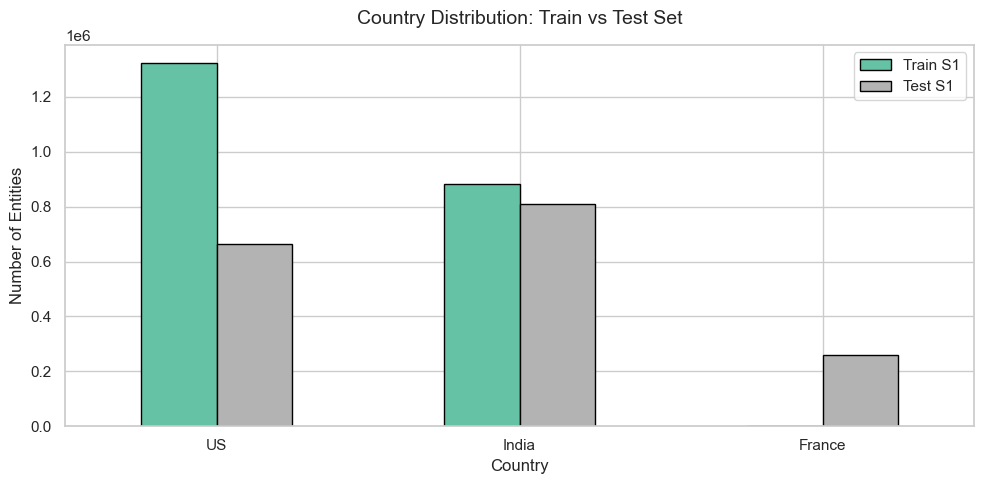

In [25]:
plt.figure(figsize=(10, 5))

# Aggregate country counts across Train S1 and Test S1
train_countries = train_s1['country'].value_counts().rename("Train S1")
test_countries = test_s1['country'].value_counts().rename("Test S1")

country_df = pd.concat([train_countries, test_countries], axis=1).fillna(0)

# Grouped bar chart
country_df.plot(kind='bar', figsize=(10, 5), colormap="Set2", edgecolor="black")

plt.title("Country Distribution: Train vs Test Set", fontsize=14, pad=15)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Number of Entities", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

=== EXACT STRING MATCH ANALYSIS (50k SAMPLE) ===
Cleaning text for 50,000 S1 entities and 172,784 known candidates...

Total True Match Pairs Analyzed: 172,784
Exact Name Matches:    44,637 (25.83%)
Exact Address Matches: 14,380 (8.32%)
Fuzzy Matches Required: 128,147 (74.17%)

=== TOP ADDRESS N-GRAM NOISE ===


/var/folders/k4/gcqzln6s2cq89xq1z0mg0b0h0000gn/T/ipykernel_25533/3012978029.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=df_freq, palette="magma")


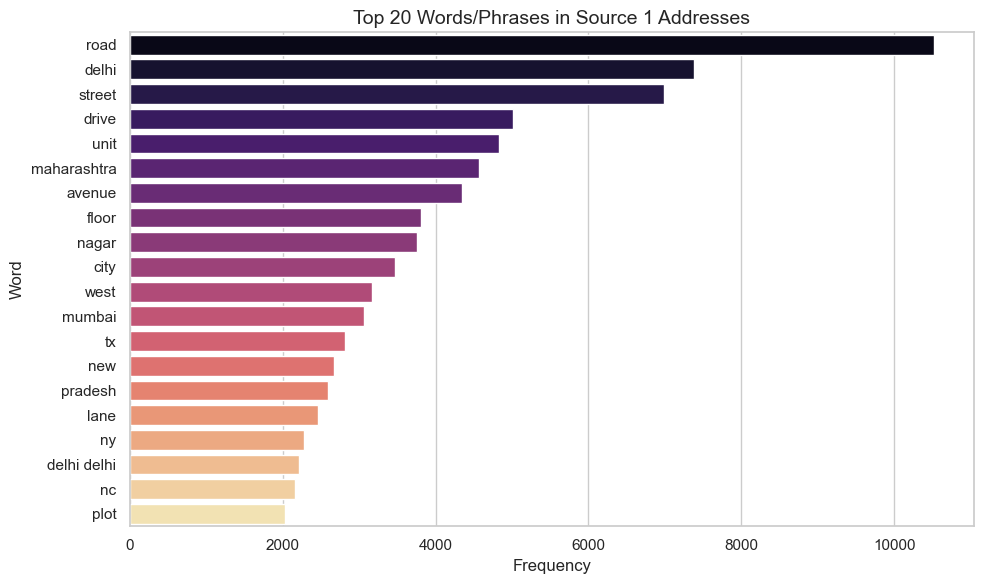

In [29]:
import pandas as pd
import numpy as np
import unicodedata
import re
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

print("=== EXACT STRING MATCH ANALYSIS (50k SAMPLE) ===")

def clean_text_fast(text):
    if pd.isna(text) or text == '': 
        return ""
    text = unicodedata.normalize('NFKD', str(text)).encode('ASCII', 'ignore').decode('utf-8').lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

# 1. Sample 50k S1 IDs
np.random.seed(42)
sample_s1_ids = set(np.random.choice(gt['source1_entity_id'].values, size=50000, replace=False))
sample_gt = gt[gt['source1_entity_id'].isin(sample_s1_ids)].copy()
sample_s1 = train_s1[train_s1['entity_id'].isin(sample_s1_ids)].copy()

# 2. Extract ONLY the necessary S2/S3 candidate IDs to save processing time
matched_ids = set()
for matches in sample_gt['matched_entity_ids'].dropna():
    for m in str(matches).split(','):
        if m.strip(): matched_ids.add(m.strip())

sample_s2 = train_s2[train_s2['entity_id'].isin(matched_ids)].copy()
sample_s3 = train_s3[train_s3['entity_id'].isin(matched_ids)].copy()

print(f"Cleaning text for {len(sample_s1):,} S1 entities and {len(sample_s2) + len(sample_s3):,} known candidates...")

# 3. Apply cleaning to create the required columns
for df in [sample_s1, sample_s2, sample_s3]:
    df['clean_name'] = df['business_name'].apply(clean_text_fast)
    df['clean_address'] = df['business_address'].apply(clean_text_fast)

# 4. Create fast lookup dictionaries for exact matching
cand_name_dict = pd.concat([sample_s2[['entity_id', 'clean_name']], sample_s3[['entity_id', 'clean_name']]]).set_index('entity_id')['clean_name'].to_dict()
cand_addr_dict = pd.concat([sample_s2[['entity_id', 'clean_address']], sample_s3[['entity_id', 'clean_address']]]).set_index('entity_id')['clean_address'].to_dict()

exact_names = 0
exact_addrs = 0
total_pairs = 0

# 5. Check exact matches for true positive pairs
for _, row in sample_gt.iterrows():
    s1_id = row['source1_entity_id']
    s1_name = sample_s1.loc[sample_s1['entity_id'] == s1_id, 'clean_name'].values
    s1_addr = sample_s1.loc[sample_s1['entity_id'] == s1_id, 'clean_address'].values
    
    if len(s1_name) == 0: continue
    s1_n, s1_a = str(s1_name[0]), str(s1_addr[0])
    
    raw_matches = row['matched_entity_ids']
    matches = set([m.strip() for m in str(raw_matches).split(',') if m.strip()]) if pd.notna(raw_matches) else set()
    
    for match_id in matches:
        if match_id in cand_name_dict:
            total_pairs += 1
            if s1_n != "" and s1_n == str(cand_name_dict[match_id]): exact_names += 1
            if s1_a != "" and s1_a == str(cand_addr_dict[match_id]): exact_addrs += 1

if total_pairs > 0:
    print(f"\nTotal True Match Pairs Analyzed: {total_pairs:,}")
    print(f"Exact Name Matches:    {exact_names:,} ({(exact_names/total_pairs)*100:.2f}%)")
    print(f"Exact Address Matches: {exact_addrs:,} ({(exact_addrs/total_pairs)*100:.2f}%)")
    print(f"Fuzzy Matches Required: {(total_pairs - max(exact_names, exact_addrs)):,} ({((total_pairs - max(exact_names, exact_addrs))/total_pairs)*100:.2f}%)")

print("\n=== TOP ADDRESS N-GRAM NOISE ===")
def plot_top_ngrams(corpus, title, n=20):
    vec = CountVectorizer(stop_words='english', ngram_range=(1, 2)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:n]
    
    df_freq = pd.DataFrame(words_freq, columns=['Word', 'Frequency'])
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Frequency', y='Word', data=df_freq, palette="magma")
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# Drop empties to avoid CountVectorizer errors
s1_clean_addrs = sample_s1['clean_address'][sample_s1['clean_address'] != '']
if len(s1_clean_addrs) > 0:
    plot_top_ngrams(s1_clean_addrs, "Top 20 Words/Phrases in Source 1 Addresses")